
# 🌾 Seasonal Agriculture Performance Analysis

**VOIS AICTE Major Project 2026–2027**

### Project Goal
Analyze how agricultural performance changes across **Kharif, Rabi and Zaid** seasons using the provided agriculture dataset.

### Tools
- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Seaborn

### Analysis covered
1. Dataset understanding
2. Data cleaning and missing-value treatment
3. Seasonal comparison
4. Environmental and resource analysis
5. Production, revenue and profit analysis
6. Relationship/correlation analysis
7. Statistical analysis
8. Visualizations
9. Key findings and recommendations



## 1. Import Libraries

Run this cell first.


In [9]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)



## 2. Upload the Provided Dataset

Click **Choose Files** and upload the Excel file


In [8]:
df = pd.read_excel("/content/seasonal_agriculture_performance_dataset (2).csv.xlsx")

In [12]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3



## 3. Understand the Dataset

Check the number of records, columns, data types and basic statistics.


In [16]:

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 records:")
display(df.head())

print("\nNumerical Statistics:")
print(df.describe())

Number of rows: 4000
Number of columns: 28

Column Names:
Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

Data Types:
Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct  

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3



Numerical Statistics:
       Farm_Area_Hectares  Rainfall_mm  Avg_Temperature_C  Humidity_pct  \
count         4000.000000  3952.000000         4000.00000   4000.000000   
mean             7.888265   601.152657           26.81890     63.210500   
std              4.223764   288.925025            3.81818     11.960834   
min              0.500000    80.000000           16.20000     25.000000   
25%              4.260000   370.200000           23.90000     54.775000   
50%              7.895000   582.000000           26.90000     63.000000   
75%             11.650000   834.950000           29.60000     71.900000   
max             15.000000  1395.200000           39.70000     95.000000   

       Sunlight_Hours_Day      Soil_pH  Soil_Moisture_pct  Nitrogen_kg_ha  \
count         4000.000000  4000.000000        3960.000000     4000.000000   
mean             7.323050     6.701010          26.508232      120.250825   
std              1.121186     0.641461           6.712484       31.216


## 4. Data Quality Check

We check missing values and duplicate records before analysis.


In [14]:

missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

print("Missing values by column:")
display(missing.to_frame("Missing Values"))

print("Total missing values:", int(df.isnull().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))


Missing values by column:


,Missing Values
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


Total missing values: 120
Duplicate rows: 0



## 5. Data Cleaning

- Duplicate rows are removed.
- Numeric missing values are filled using the **median of the same season** where possible.
- If a numeric column has no seasonal value available, its overall median is used.
- We do not automatically delete extreme observations; they are checked separately as possible outliers.


In [17]:

df = df.drop_duplicates().copy()

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

for col in numeric_cols:
    if "Season" in df.columns:
        df[col] = df.groupby("Season")[col].transform(
            lambda x: x.fillna(x.median())
        )
    df[col] = df[col].fillna(df[col].median())

print("Missing values after cleaning:", int(df.isnull().sum().sum()))
print("Rows after removing duplicates:", len(df))


Missing values after cleaning: 0
Rows after removing duplicates: 4000



## 6. Explore the Seasons
The project focuses on seasonal variation, so first we examine the number of farms/records in each season.

### Analytical Question
**How many agricultural records are available for each season?**


Records by season:


,Records
Season,
Kharif,1779
Rabi,1627
Zaid,594


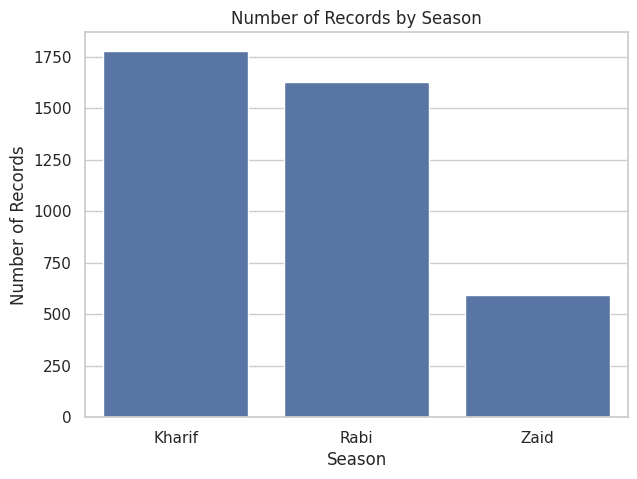

In [18]:

season_counts = df["Season"].value_counts()

print("Records by season:")
display(season_counts.to_frame("Records"))

plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Season", order=season_counts.index)
plt.title("Number of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.show()



## 7. Seasonal Performance Comparison
### Analytical Question
**How does agricultural performance vary across Kharif, Rabi and Zaid seasons in terms of yield, production, revenue, cost and profit?**

This section compares the major agricultural performance indicators across seasons.


In [20]:

season_summary = df.groupby("Season").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield_Tonnes_Ha=("Yield_Tonnes_Ha", "mean"),
    Avg_Production_Tonnes=("Production_Tonnes", "mean"),
    Avg_Revenue_INR=("Revenue_INR", "mean"),
    Avg_Cost_INR=("Total_Cost_INR", "mean"),
    Avg_Profit_INR=("Profit_INR", "mean"),
    Avg_Water_Used_m3=("Water_Used_m3", "mean"),
    Avg_Disease_Risk_pct=("Disease_Pest_Risk_pct", "mean")
).round(2)

display(season_summary)


,Farms,Avg_Yield_Tonnes_Ha,Avg_Production_Tonnes,Avg_Revenue_INR,Avg_Cost_INR,Avg_Profit_INR,Avg_Water_Used_m3,Avg_Disease_Risk_pct
Season,,,,,,,,
Kharif,1779,5.63,46.31,710719.06,531804.41,178914.65,6102.20,54.47
Rabi,1627,5.04,41.49,601526.05,513836.58,87689.47,5846.99,40.48
Zaid,594,4.64,38.89,519171.90,543976.73,-24804.82,6419.89,38.22


In [ ]:

# Yield comparison
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Season", y="Yield_Tonnes_Ha", estimator="mean", errorbar=None)
plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.show()

# Profit comparison
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Season", y="Profit_INR", estimator="mean", errorbar=None)
plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.show()

# Production comparison
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Season", y="Production_Tonnes", estimator="mean", errorbar=None)
plt.title("Average Production by Season")
plt.xlabel("Season")
plt.ylabel("Average Production (Tonnes)")
plt.show()


## 8. Environmental Conditions by Season

### Analytical Question
**How do environmental conditions such as rainfall, temperature, humidity, sunlight and soil moisture differ across seasons?**

This section compares the main environmental conditions across Kharif, Rabi and Zaid seasons.

,Rainfall_mm,Temperature_C,Humidity_pct,Sunlight_Hours,Soil_Moisture_pct
Season,,,,,
Kharif,852.11,28.45,71.81,6.79,31.20
Rabi,435.94,23.49,57.89,7.59,24.05
Zaid,299.12,31.04,52.01,8.18,19.17


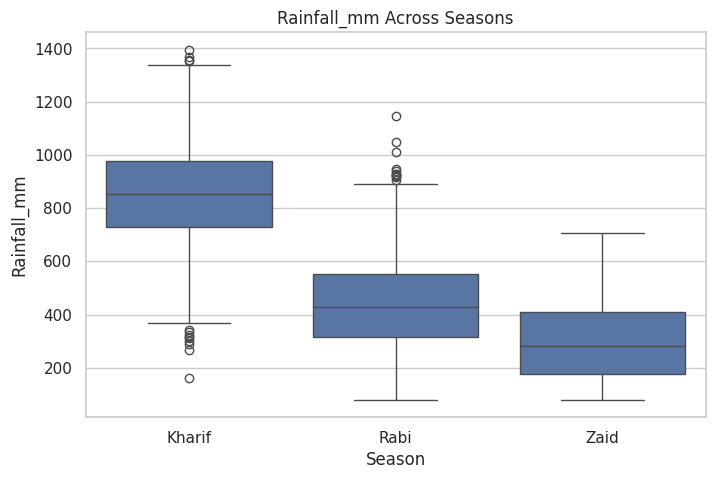

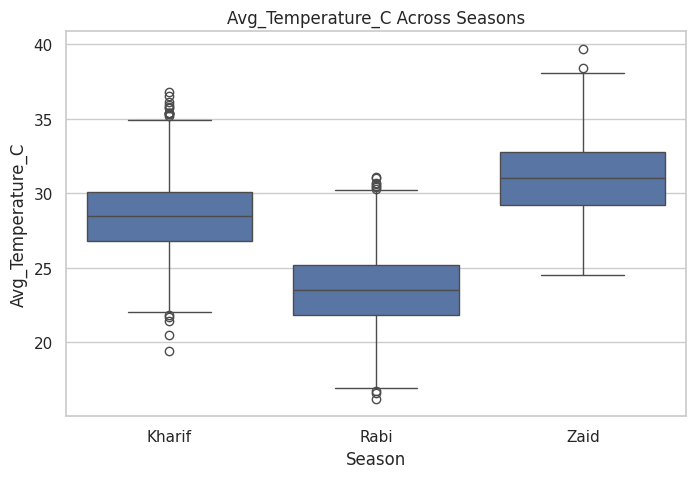

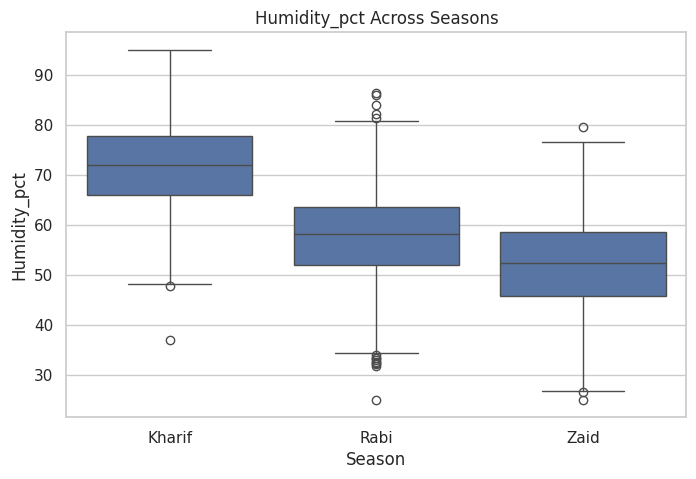

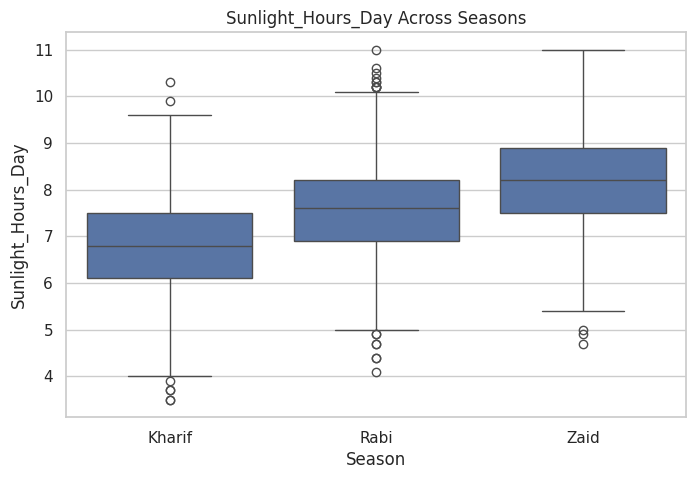

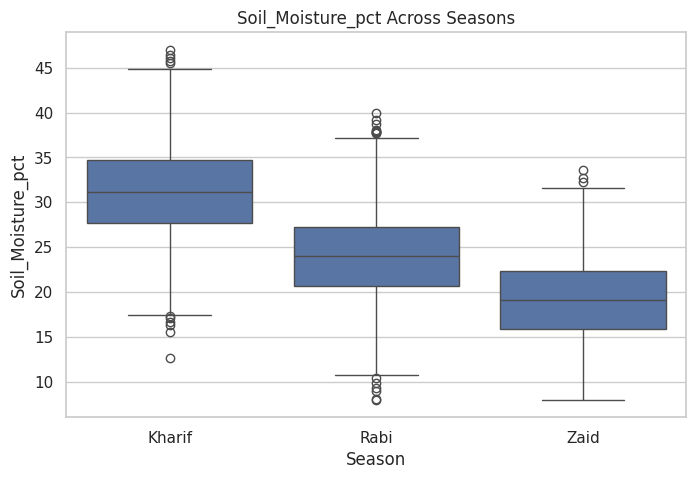

In [21]:

environment_summary = df.groupby("Season").agg(
    Rainfall_mm=("Rainfall_mm", "mean"),
    Temperature_C=("Avg_Temperature_C", "mean"),
    Humidity_pct=("Humidity_pct", "mean"),
    Sunlight_Hours=("Sunlight_Hours_Day", "mean"),
    Soil_Moisture_pct=("Soil_Moisture_pct", "mean")
).round(2)

display(environment_summary)

environment_cols = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_Moisture_pct"
]

for col in environment_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df, x="Season", y=col)
    plt.title(f"{col} Across Seasons")
    plt.xlabel("Season")
    plt.ylabel(col)
    plt.show()


## 9. Resource and Farming Practice Analysis

### Analytical Question
**How does the use of irrigation, fertilizer, pesticides and water vary across different seasons?**

This section examines differences in resource usage and farming practices across seasons.

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,405,590,463,321
Rabi,370,526,438,293
Zaid,140,194,140,120


,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Water_Efficiency,Seed_Quality
Season,,,,,
Kharif,187.08,5.08,6102.20,5.89,0.82
Rabi,185.41,5.02,5846.99,5.19,0.83
Zaid,184.64,5.17,6419.89,4.41,0.82


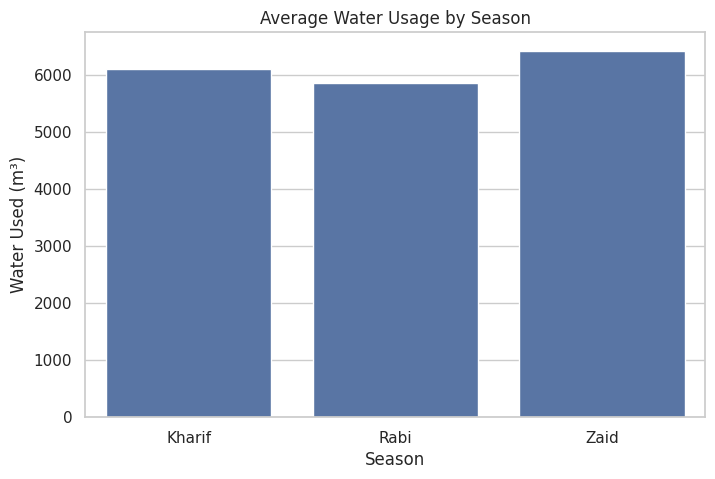

In [22]:

irrigation_table = pd.crosstab(df["Season"], df["Irrigation_Method"])
display(irrigation_table)

resource_summary = df.groupby("Season").agg(
    Fertilizer_kg_ha=("Fertilizer_kg_ha", "mean"),
    Pesticide_Litre_ha=("Pesticide_Litre_ha", "mean"),
    Water_Used_m3=("Water_Used_m3", "mean"),
    Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Seed_Quality=("Seed_Quality_Score", "mean")
).round(2)

display(resource_summary)

plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Season", y="Water_Used_m3", estimator="mean", errorbar=None)
plt.title("Average Water Usage by Season")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")
plt.show()


## 10. Crop-wise and State-wise Analysis

### Analytical Question 1
**How does agricultural performance vary across different crops?**

### Analytical Question 2
**How does agricultural performance vary across different states?**

This section compares yield, production and profit across crops and states to identify important patterns in agricultural performance.

In [23]:

crop_summary = df.groupby("Crop").agg(
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Production=("Production_Tonnes", "mean")
).sort_values("Avg_Yield", ascending=False).round(2)

print("Crop-wise performance:")
display(crop_summary)

state_summary = df.groupby("State").agg(
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Production=("Production_Tonnes", "mean")
).sort_values("Avg_Yield", ascending=False).round(2)

print("State-wise performance:")
display(state_summary)


Crop-wise performance:


,Avg_Yield,Avg_Profit,Avg_Production
Crop,,,
Sugarcane,46.64,817187.99,392.41
Maize,2.71,-83978.33,21.78
Rice,2.43,-102213.50,19.29
Wheat,2.11,-123398.34,16.85
Chilli,1.54,750878.34,12.38
Groundnut,1.32,44858.12,9.66
Cotton,1.23,124546.92,9.40
Pulses,0.92,-4238.05,7.40


State-wise performance:


,Avg_Yield,Avg_Profit,Avg_Production
State,,,
Punjab,6.12,136025.64,52.23
Karnataka,5.69,119422.34,47.73
Gujarat,5.66,117568.24,48.33
Telangana,5.04,108829.62,39.25
Maharashtra,5.02,135428.86,43.98
Madhya Pradesh,4.99,86840.76,37.56
Tamil Nadu,4.87,117744.75,40.84
Andhra Pradesh,4.63,73453.53,36.91


## 11. Relationship Between Variables

### Analytical Question
**What relationships exist between environmental conditions, resource usage and agricultural performance?**

Correlation analysis is used to identify variables that move together. Correlation does **not** by itself prove causation.

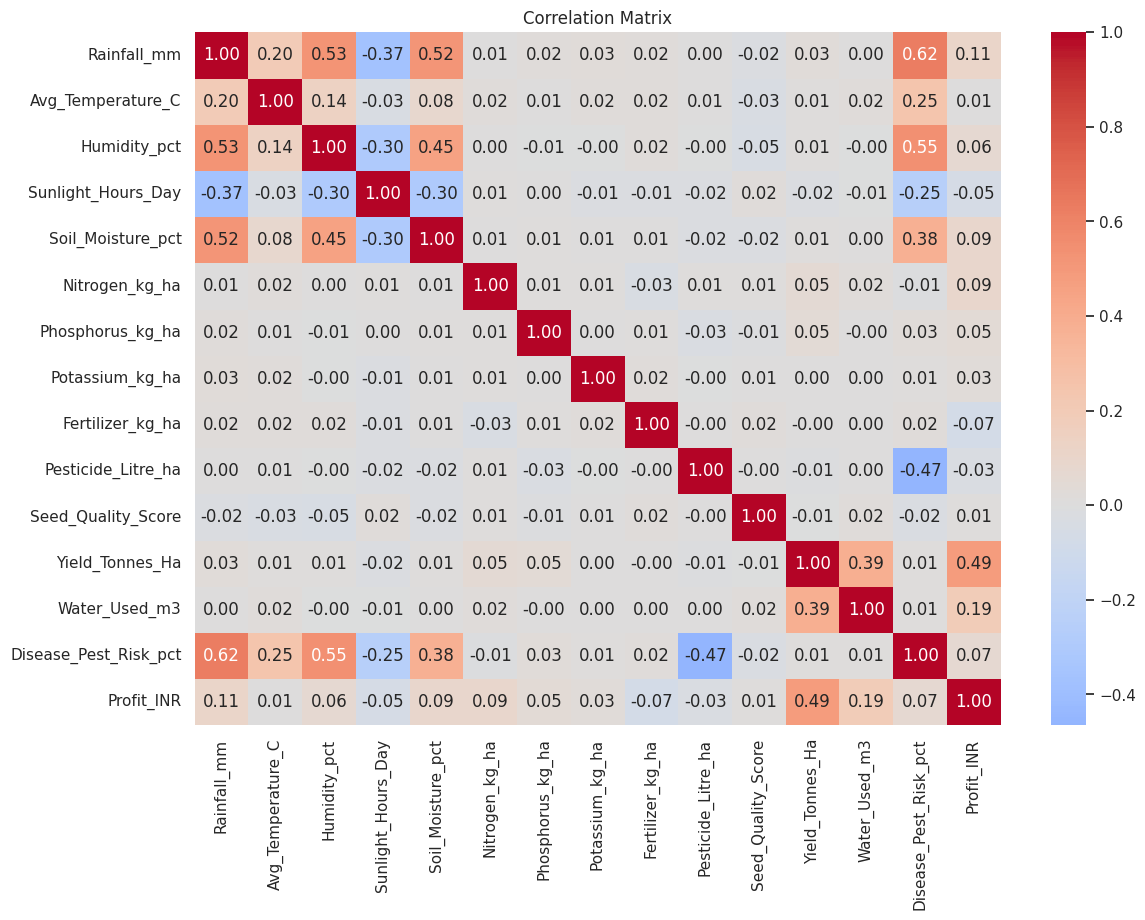

Variables most strongly associated with Yield_Tonnes_Ha:


,Correlation with Yield
Profit_INR,0.488459
Water_Used_m3,0.386298
Nitrogen_kg_ha,0.053167
Phosphorus_kg_ha,0.047974
Rainfall_mm,0.028836
Sunlight_Hours_Day,-0.015362
Disease_Pest_Risk_pct,0.014351
Humidity_pct,0.012337
Soil_Moisture_pct,0.011101
Avg_Temperature_C,0.010026


In [25]:

corr_cols = [
    "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
    "Sunlight_Hours_Day", "Soil_Moisture_pct",
    "Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha",
    "Fertilizer_kg_ha", "Pesticide_Litre_ha",
    "Seed_Quality_Score", "Yield_Tonnes_Ha",
    "Water_Used_m3", "Disease_Pest_Risk_pct",
    "Profit_INR"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(13,9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

yield_corr = corr["Yield_Tonnes_Ha"].drop("Yield_Tonnes_Ha").sort_values(
    key=lambda x: x.abs(), ascending=False
)

print("Variables most strongly associated with Yield_Tonnes_Ha:")
display(yield_corr.to_frame("Correlation with Yield"))


## 12. Seasonal Yield Comparison

### Analytical Question
**How does the distribution of crop yield differ across Kharif, Rabi and Zaid seasons?**

This section compares the mean, median and standard deviation of yield for each season using Pandas and NumPy only.

In [27]:
# Seasonal yield comparison using Pandas and NumPy
season_yield_summary = df.groupby("Season")["Yield_Tonnes_Ha"].agg(
    ["count", "mean", "median", "std"]
).round(2)

display(season_yield_summary)

highest_yield_season = season_yield_summary["mean"].idxmax()
lowest_yield_season = season_yield_summary["mean"].idxmin()

yield_difference = (
    season_yield_summary.loc[highest_yield_season, "mean"]
    - season_yield_summary.loc[lowest_yield_season, "mean"]
)

print(f"Highest average yield: {highest_yield_season}")
print(f"Lowest average yield: {lowest_yield_season}")
print(f"Difference between highest and lowest average yield: {yield_difference:.2f} tonnes/ha")


,count,mean,median,std
Season,,,,
Kharif,1779,5.63,1.95,14.39
Rabi,1627,5.04,1.66,12.75
Zaid,594,4.64,1.45,11.27


Highest average yield: Kharif
Lowest average yield: Zaid
Difference between highest and lowest average yield: 0.99 tonnes/ha


## 13. Outlier Check

### Analytical Question
**Are there any unusually high or low values in the agricultural performance data?**

Extreme values are flagged using the IQR method. They are **not automatically deleted**, because an extreme agricultural observation may be a genuine observation.

In [28]:

def iqr_outlier_count(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

outlier_results = {
    col: iqr_outlier_count(df[col])
    for col in ["Yield_Tonnes_Ha", "Production_Tonnes", "Profit_INR", "Water_Used_m3"]
}

display(pd.Series(outlier_results, name="Possible IQR Outliers").to_frame())


,Possible IQR Outliers
Yield_Tonnes_Ha,302
Production_Tonnes,333
Profit_INR,404
Water_Used_m3,276



## 14.  Key Findings

This section produces data-based statements from the results instead of using invented values.


In [30]:

# Key Findings

yield_means = df.groupby("Season")["Yield_Tonnes_Ha"].mean()
profit_means = df.groupby("Season")["Profit_INR"].mean()
water_means = df.groupby("Season")["Water_Used_m3"].mean()
risk_means = df.groupby("Season")["Disease_Pest_Risk_pct"].mean()

print("KEY FINDINGS")
print("------------")

print(f"1. Highest average yield: {yield_means.idxmax()} ({yield_means.max():.2f} tonnes/ha)")
print(f"2. Lowest average yield: {yield_means.idxmin()} ({yield_means.min():.2f} tonnes/ha)")
print(f"3. Highest average profit: {profit_means.idxmax()} (₹{profit_means.max():,.2f})")
print(f"4. Lowest average profit: {profit_means.idxmin()} (₹{profit_means.min():,.2f})")
print(f"5. Highest water usage: {water_means.idxmax()} ({water_means.max():,.2f} m³)")
print(f"6. Highest disease/pest risk: {risk_means.idxmax()} ({risk_means.max():.2f}%)")


KEY FINDINGS
------------
1. Highest average yield: Kharif (5.63 tonnes/ha)
2. Lowest average yield: Zaid (4.64 tonnes/ha)
3. Highest average profit: Kharif (₹178,914.65)
4. Lowest average profit: Zaid (₹-24,804.82)
5. Highest water usage: Zaid (6,419.89 m³)
6. Highest disease/pest risk: Kharif (54.47%)



## 15. Data-Based Recommendations

Use the findings above to write recommendations. The following points are a framework; edit them to match your actual results.

1. **Seasonal planning:** Use seasonal yield and profit patterns when planning crop and resource allocation.
2. **Water management:** Pay attention to seasons with high water use and compare them with water-efficiency results.
3. **Environmental monitoring:** Monitor rainfall, temperature, humidity and soil moisture during seasons with lower performance.
4. **Crop planning:** Use crop-wise and seasonal performance together when selecting crops for future planning.
5. **Risk management:** Seasons with higher disease/pest risk may require closer monitoring and timely preventive measures.
6. **Evidence-based decisions:** Use the observed data patterns rather than relying only on assumptions about seasonal performance.


# Conclusion

This project analyzed seasonal agricultural performance using Python and data analytics techniques. The dataset was cleaned and explored to understand seasonal differences in yield, production, environmental conditions, resource usage, water efficiency, disease and pest risk, and financial performance.

Visualizations, correlation analysis and statistical analysis were used to identify important patterns and relationships in the dataset. The findings provide data-based insights that can support better seasonal planning and agricultural decision-making.
